In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')
sys.path.insert(0, '../../../../../..')

# Decoding
import suffix_pred.evalaution.decode_test_set_suffixes
importlib.reload(suffix_pred.evalaution.decode_test_set_suffixes)
from suffix_pred.evalaution.decode_test_set_suffixes import TestSetSuffixDecoder, DecodingConfig

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

# Model
import suffix_pred.models.C_LSTM
importlib.reload(suffix_pred.models.C_LSTM)
from suffix_pred.models.C_LSTM import FullShared_Join_LSTM

In [2]:
# Model
file_path_model = '../../../../../../models/Sepsis/decision/Sepsis_C_LSTM_v1_DA.pkl'
model = FullShared_Join_LSTM.load(file_path_model)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../../data/Sepsis/tensor_data/normal/sepsis_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 28, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Model input features:  [['concept:name', 'org:group'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(18, 8)
  (1): Embedding(28, 10)
)
Total embedd

/home/PSPLab/.local/share/virtualenvs/decision_aware_augmentation_for_PPM-0DzgvVpC/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [3]:
# Step 1: Decode suffixes (mode / arg-max)
config = DecodingConfig(concept_name="concept:name",
                        eos_value="EOS")

decoder = TestSetSuffixDecoder(model=model, dataset=test_dataset, config=config)

mode = "mode"
outputs = decoder.decode(mode=mode,
                         random_order=False,
                         cache_path="../../../../../../eval_results/Sepsis/decision_train/sepsis_c_lstm_mode_decision_train_outputs.pkl",
                         reuse_cache=False)

print(f"Decoded {len(outputs)} prefix rows in '{mode}' mode")

# Step 2: Evaluate DLS from decoded outputs
mode_df = evaluate_dls(outputs)
mode_per_prefix = dls_per_prefix_length(mode_df)
mode_avg = average_dls(mode_df)

print(f"Average DLS ({mode}) on full test set: {mode_avg:.4f}")

  0%|          | 0/209 [00:00<?, ?it/s]

Decoded 2648 prefix rows in 'mode' mode
Average DLS (mode) on full test set: 0.4539


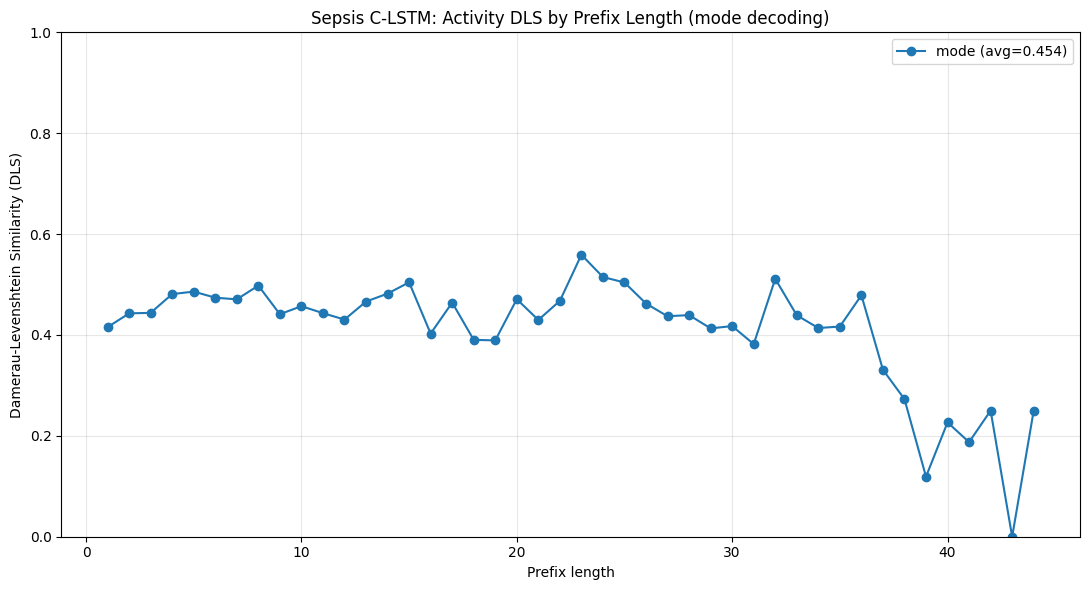

,mode,average_dls
0,mode,0.45389


In [4]:
# One combined plot (single method requested: mode decoding only)
plt.figure(figsize=(11, 6))

plt.plot(mode_per_prefix["prefix_len"],
         mode_per_prefix["dls"],
         marker="o",
         label=f"mode (avg={mode_avg:.3f})")

plt.title("Sepsis C-LSTM: Activity DLS by Prefix Length (mode decoding)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({"mode": [mode], "average_dls": [mode_avg]}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [5]:
# Load decoded outputs from pickle and inspect 5 example prefixes
from suffix_pred.evalaution.evalaution_metrics import load_decoded_suffixes

cached_outputs = load_decoded_suffixes("../../../../../../eval_results/Sepsis/decision_train/sepsis_c_lstm_mode_decision_train_outputs.pkl")

for row in cached_outputs[:15]:
    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row["decoded_suffixes"]
    print(f"  Predicted suffix:  {decoded[0] if len(decoded) > 0 else []}")
    print()

Case: AAA  |  Prefix len: 1
  Prefix:            ['ER Registration']
  Target suffix:     ['ER Triage', 'ER Sepsis Triage', 'IV Liquid', 'Leucocytes', 'CRP', 'LacticAcid', 'IV Antibiotics', 'Admission NC', 'Release A', 'Return ER']
  Predicted suffix:  ['Return ER', 'ER Sepsis Triage', 'LacticAcid', 'Leucocytes', 'CRP', 'IV Liquid', 'IV Antibiotics', 'Admission NC', 'CRP', 'Leucocytes', 'CRP', 'Leucocytes', 'Release A']

Case: AAA  |  Prefix len: 2
  Prefix:            ['ER Registration', 'ER Triage']
  Target suffix:     ['ER Sepsis Triage', 'IV Liquid', 'Leucocytes', 'CRP', 'LacticAcid', 'IV Antibiotics', 'Admission NC', 'Release A', 'Return ER']
  Predicted suffix:  ['ER Sepsis Triage', 'LacticAcid', 'Leucocytes', 'CRP', 'IV Antibiotics', 'Admission NC', 'Admission NC', 'CRP', 'Leucocytes', 'CRP', 'Leucocytes', 'CRP', 'Leucocytes', 'Release A']

Case: AAA  |  Prefix len: 3
  Prefix:            ['ER Registration', 'ER Triage', 'ER Sepsis Triage']
  Target suffix:     ['IV Liquid', 'L